# Deutsch-Jozsa Quantum Algorithm Analysis

In [1]:
import json
import os
import random
from itertools import product
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit.quantum_info as qi
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Operator, Statevector
from qiskit_aer import AerSimulator

In [2]:
os.makedirs('data', exist_ok=True)
os.makedirs('img', exist_ok=True)

## Problem 1: Generating Random Boolean Functions.

In the Deutsch-Jozsa setting, a **constant** Boolean function returns the same value for every input, while a **balanced** Boolean function returns True for exactly half of the inputs and False for the other half. These two categories are the core promise the algorithm exploits.

**Research:** A 4-bit input space has $2^4 = 16$ possible inputs. A balanced 4-bit function therefore returns True for exactly 8 inputs and False for the remaining 8. This distinction is crucial for validating that the Deutsch-Jozsa algorithm can separate constant from balanced functions with a single query (see the overview in [IBM Quantum Learning](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-oracles)).

> Programming perspective: to guarantee balance, we construct a list with eight True values and eight False values, then shuffle it to randomize the mapping while preserving the 8/8 split.

In [3]:
def random_constant_balanced(seed: int | None = None) -> Callable[[bool, bool, bool, bool], bool]:
    """Return a random 4-bit Boolean function that is constant or balanced.

    Args:
        seed: Optional seed for reproducibility.

    Returns:
        A callable f(a, b, c, d) -> bool representing the Boolean function.
    """
    # Create a local RNG to avoid global state and enable reproducibility.
    rng = random.Random(seed)

    # Randomly pick whether the function is constant or balanced.
    function_type = rng.choice(["constant", "balanced"])

    # Enumerate all 16 possible 4-bit inputs.
    inputs = list(product([False, True], repeat=4))

    if function_type == "constant":
        # Choose the single value returned for every input.
        constant_value = rng.choice([False, True])

        def oracle(a: bool, b: bool, c: bool, d: bool) -> bool:
            """Constant 4-bit Boolean function."""
            # Ignore inputs to return the same value every time.
            return constant_value

        return oracle

    # For a balanced function, assign exactly 8 True and 8 False values.
    outputs = [True] * 8 + [False] * 8
    # Shuffle to randomize the mapping while preserving balance.
    rng.shuffle(outputs)

    mapping = dict(zip(inputs, outputs))

    def oracle(a: bool, b: bool, c: bool, d: bool) -> bool:
        """Balanced 4-bit Boolean function."""
        # Look up the output for the given input tuple.
        return mapping[(a, b, c, d)]

    return oracle

In [4]:
# Reproducible example using a fixed seed.
test_oracle = random_constant_balanced(seed=42)

truth_table = {
    inputs: test_oracle(*inputs)
    for inputs in product([False, True], repeat=4)
}

true_count = sum(truth_table.values())
false_count = len(truth_table) - true_count

if true_count in (0, 16):
    function_label = "constant"
elif true_count == 8:
    function_label = "balanced"
else:
    function_label = "unexpected"

print("Function type:", function_label)
print("True count:", true_count, "False count:", false_count)
print("Sample outputs (first 5):", list(truth_table.items())[:5])

Function type: constant
True count: 0 False count: 16
Sample outputs (first 5): [((False, False, False, False), False), ((False, False, False, True), False), ((False, False, True, False), False), ((False, False, True, True), False), ((False, True, False, False), False)]


Truth tables and sampled function outputs are saved to `/data/` to ensure that results can be verified without re-executing stochastic code cells.

In [5]:
sampled_function_ids = ["p1_f1", "p1_f2", "p1_f3", "p1_f4", "p1_f5"]
sampled_seeds = [101, 202, 303, 404, 505]

sample_rows = []
truth_table_rows = []

for function_id, seed in zip(sampled_function_ids, sampled_seeds):
    oracle = random_constant_balanced(seed=seed)
    combinations = list(product([False, True], repeat=4))

    outputs = [int(oracle(*bits)) for bits in combinations]
    true_count = sum(outputs)
    function_type = "constant" if true_count in (0, 16) else "balanced"

    for bits, output in zip(combinations, outputs):
        a, b, c, d = [int(bit) for bit in bits]
        bitstring = f"{a}{b}{c}{d}"

        sample_rows.append(
            {
                "function_id": function_id,
                "input": bitstring,
                "output": output,
            }
        )

        truth_table_rows.append(
            {
                "function_id": function_id,
                "function_type": function_type,
                "a": a,
                "b": b,
                "c": c,
                "d": d,
                "output": output,
            }
        )

p1_sample_df = pd.DataFrame(sample_rows)
p1_truth_table_df = pd.DataFrame(truth_table_rows)

p1_sample_df.to_csv('data/p1_random_function_samples.csv', index=False)
p1_truth_table_df.to_csv('data/p1_truth_tables.csv', index=False)

print("Saved:", 'data/p1_random_function_samples.csv')
print("Saved:", 'data/p1_truth_tables.csv')
print(p1_truth_table_df.groupby("function_type")["function_id"].nunique())

Saved: data/p1_random_function_samples.csv
Saved: data/p1_truth_tables.csv
function_type
balanced    1
constant    4
Name: function_id, dtype: int64


## Problem 2: Classical Testing for Function Type

In the classical setting, we may need to evaluate many inputs to decide whether a promised Boolean function is constant or balanced. This makes classical testing a baseline for comparison with the Deutsch-Jozsa quantum approach, which can identify the type with far fewer oracle queries under the same promise.

For an $n$-bit function, there are $2^n$ possible inputs. In the worst classical case, you must inspect one more than half of the truth table to rule out the opposite class, so query complexity scales as $O(2^n)$. For 4 bits, that means at most $2^{4-1}+1 = 9$ queries.

Reference: https://en.wikipedia.org/wiki/Deutsch%E2%80%93Jozsa_algorithm

In [6]:
def determine_constant_balanced(
    f: Callable[[bool, bool, bool, bool], bool],
) -> str:
    """Classify a promised 4-bit Boolean function as constant or balanced.

    This classical routine evaluates up to 9 inputs in the worst case
    ($2^{n-1} + 1$ for $n=4$), which is enough to distinguish constant from
    balanced under the Deutsch-Jozsa promise.

    Args:
        f: A Boolean function taking four Boolean inputs (a, b, c, d) and
            returning a Boolean output.

    Returns:
        "constant" if all queried outputs match, otherwise "balanced" when
        two different output values are observed.
    """
    input_combinations = list(product([False, True], repeat=4))

    first_result = f(*input_combinations[0])
    query_count = 1

    # For n=4, classical worst-case checks are capped at 2^(n-1)+1 = 9 calls.
    for combination in input_combinations[1:]:
        if query_count >= 9:
            break

        current_result = f(*combination)
        query_count += 1

        # Early exit: differing outputs immediately prove the function balanced.
        if current_result != first_result:
            return "balanced"

    return "constant"

In [7]:
def constant_true(a: bool, b: bool, c: bool, d: bool) -> bool:
    return True


def constant_false(a: bool, b: bool, c: bool, d: bool) -> bool:
    return False


def balanced_example(a: bool, b: bool, c: bool, d: bool) -> bool:
    return a ^ b ^ c


balanced_true_count = sum(
    balanced_example(a, b, c, d)
    for a, b, c, d in product([False, True], repeat=4)
)

print("Balanced example true-count:", balanced_true_count, "of 16")
print("constant_true   ->", determine_constant_balanced(constant_true))
print("constant_false  ->", determine_constant_balanced(constant_false))
print("balanced_example->", determine_constant_balanced(balanced_example))

Balanced example true-count: 8 of 16
constant_true   -> constant
constant_false  -> constant
balanced_example-> balanced


In [8]:
def balanced_identity(a: bool, b: bool, c: bool, d: bool) -> bool:
    return a


def balanced_negation(a: bool, b: bool, c: bool, d: bool) -> bool:
    return not a


def determine_constant_balanced_with_queries(
    f: Callable[[bool, bool, bool, bool], bool],
) -> tuple[str, int]:
    combinations = list(product([False, True], repeat=4))

    first_result = f(*combinations[0])
    query_count = 1

    for combination in combinations[1:]:
        if query_count >= 9:
            break

        current_result = f(*combination)
        query_count += 1

        if current_result != first_result:
            return "balanced", query_count

    return "constant", query_count


problem2_tests = [
    {
        "test_id": "p2_t1",
        "function_description": "constant_true (always returns True)",
        "function": constant_true,
        "expected": "constant",
    },
    {
        "test_id": "p2_t2",
        "function_description": "constant_false (always returns False)",
        "function": constant_false,
        "expected": "constant",
    },
    {
        "test_id": "p2_t3",
        "function_description": "balanced_identity (f(x) = x)",
        "function": balanced_identity,
        "expected": "balanced",
    },
    {
        "test_id": "p2_t4",
        "function_description": "balanced_negation (f(x) = NOT x)",
        "function": balanced_negation,
        "expected": "balanced",
    },
]

problem2_result_rows = []

for test_case in problem2_tests:
    result, queries_used = determine_constant_balanced_with_queries(
        test_case["function"]
    )
    problem2_result_rows.append(
        {
            "test_id": test_case["test_id"],
            "function_description": test_case["function_description"],
            "queries_used": queries_used,
            "result": result,
            "correct": result == test_case["expected"],
        }
    )

results_df = pd.DataFrame(problem2_result_rows)

# Saving test results to /data/ for reproducibility and audit purposes.
# A reviewer can inspect query counts without re-running the test suite.
results_df.to_csv('data/p2_query_test_results.csv', index=False)

print("Saved:", 'data/p2_query_test_results.csv')
print(results_df)

Saved: data/p2_query_test_results.csv
  test_id                   function_description  queries_used    result  \
0   p2_t1    constant_true (always returns True)             9  constant   
1   p2_t2  constant_false (always returns False)             9  constant   
2   p2_t3           balanced_identity (f(x) = x)             9  balanced   
3   p2_t4       balanced_negation (f(x) = NOT x)             9  balanced   

   correct  
0     True  
1     True  
2     True  
3     True  


**Efficiency note:** This classical baseline needs up to $2^{n-1}+1$ oracle calls in the promised Deutsch-Jozsa setting, so runtime grows exponentially with input size ($O(2^n)$). By contrast, the quantum Deutsch-Jozsa approach is designed to separate constant and balanced functions with dramatically fewer queries; see [IBM Quantum Learning](https://learning.quantum.ibm.com/).

## Problem 3: Quantum Oracles

A quantum oracle is a unitary black-box transformation that maps $|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$, where $\oplus$ denotes XOR, $|x\rangle$ is the input (control) qubit, and $|y\rangle$ is the target qubit. The oracle writes function information into the target register while preserving reversibility.

Classical Python Boolean functions cannot be used directly inside quantum algorithms because they are not guaranteed to be reversible or unitary. They must be wrapped into quantum circuits so that each operation can be represented as a valid unitary gate sequence.

In query-complexity theory, oracles are treated as black boxes: we focus on how many oracle calls are needed, rather than internal implementation details. Following the [IBM Quantum Learning guide on quantum query algorithms](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms), we implement each oracle as a phase-insensitive unitary transformation suitable for Deutsch-style analysis. Circuit construction follows the [Qiskit QuantumCircuit API](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit).

In [9]:
def oracle_constant_0() -> QuantumCircuit:
    """Constructs the quantum oracle for the constant-0 function.

    This oracle implements f(x) = 0 for all x in {0, 1}.
    The target qubit is left unchanged since the function never outputs 1.

    Args:
        None.

    Returns:
        QuantumCircuit: A 2-qubit circuit with qubit 0 as input
            and qubit 1 as the oracle target.

    Example:
        >>> qc = oracle_constant_0()
        >>> qc.draw()
    """
    oracle_circuit = QuantumCircuit(2)

    # The target qubit is never flipped because f(x) = 0 for all x.
    # This represents a trivially constant function.
    return oracle_circuit

In [10]:
def oracle_constant_1() -> QuantumCircuit:
    """Constructs the quantum oracle for the constant-1 function.

    This oracle implements f(x) = 1 for all x in {0, 1}.
    The target qubit is always flipped, independent of the input qubit.

    Args:
        None.

    Returns:
        QuantumCircuit: A 2-qubit circuit with qubit 0 as input
            and qubit 1 as the oracle target.

    Example:
        >>> qc = oracle_constant_1()
        >>> qc.draw()
    """
    oracle_circuit = QuantumCircuit(2)

    # X gate unconditionally flips the target qubit, encoding f(x) = 1
    # for all inputs — a constant function that always outputs True.
    oracle_circuit.x(1)
    return oracle_circuit

In [11]:
def oracle_identity() -> QuantumCircuit:
    """Constructs the quantum oracle for the identity balanced function.

    This oracle implements f(0) = 0 and f(1) = 1, equivalent to f(x) = x.
    The target qubit flips only when the input qubit is |1>.

    Args:
        None.

    Returns:
        QuantumCircuit: A 2-qubit circuit with qubit 0 as input
            and qubit 1 as the oracle target.

    Example:
        >>> qc = oracle_identity()
        >>> qc.draw()
    """
    oracle_circuit = QuantumCircuit(2)

    # CNOT flips the target qubit ONLY when the control qubit is |1>,
    # directly encoding f(x) = x. This creates input-output entanglement,
    # which is the key property Deutsch's algorithm exploits.
    oracle_circuit.cx(0, 1)
    return oracle_circuit

In [12]:
def oracle_negation() -> QuantumCircuit:
    """Constructs the quantum oracle for the negation balanced function.

    This oracle implements f(0) = 1 and f(1) = 0, equivalent to f(x) = NOT x.
    The control qubit is temporarily inverted so CNOT activates on |0> input.

    Args:
        None.

    Returns:
        QuantumCircuit: A 2-qubit circuit with qubit 0 as input
            and qubit 1 as the oracle target.

    Example:
        >>> qc = oracle_negation()
        >>> qc.draw()
    """
    oracle_circuit = QuantumCircuit(2)

    # X on the control qubit temporarily flips |0> to |1>, so CNOT fires
    # on the original |0> input and not on |1> — effectively implementing
    # f(x) = NOT x without permanently disturbing the input register.
    oracle_circuit.x(0)
    oracle_circuit.cx(0, 1)
    oracle_circuit.x(0)
    return oracle_circuit

In [13]:
oracles = {
    "oracle_constant_0": oracle_constant_0(),
    "oracle_constant_1": oracle_constant_1(),
    "oracle_identity": oracle_identity(),
    "oracle_negation": oracle_negation(),
}

unitaries = {}
for name, circuit in oracles.items():
    matrix = qi.Operator(circuit).data
    unitaries[name] = {
        "real": np.real(matrix).tolist(),
        "imag": np.imag(matrix).tolist(),
    }

with open('data/p3_oracle_unitaries.json', 'w', encoding='utf-8') as file:
    json.dump(unitaries, file, indent=2)

statevectors = {}
for name, circuit in oracles.items():
    prep_00 = QuantumCircuit(2)
    prep_10 = QuantumCircuit(2)
    prep_10.x(0)

    output_00 = Statevector.from_instruction(prep_00.compose(circuit))
    output_10 = Statevector.from_instruction(prep_10.compose(circuit))

    statevectors[name] = {
        "input_00": {
            "amplitudes_real": np.real(output_00.data).tolist(),
            "amplitudes_imag": np.imag(output_00.data).tolist(),
        },
        "input_10": {
            "amplitudes_real": np.real(output_10.data).tolist(),
            "amplitudes_imag": np.imag(output_10.data).tolist(),
        },
    }

# Raw statevector data saved to /data/ so circuit behavior
# can be verified analytically without re-running the simulator.
with open('data/p3_statevector_results.json', 'w', encoding='utf-8') as file:
    json.dump(statevectors, file, indent=2)

print("Saved:", 'data/p3_oracle_unitaries.json')
print("Saved:", 'data/p3_statevector_results.json')

Saved: data/p3_oracle_unitaries.json
Saved: data/p3_statevector_results.json


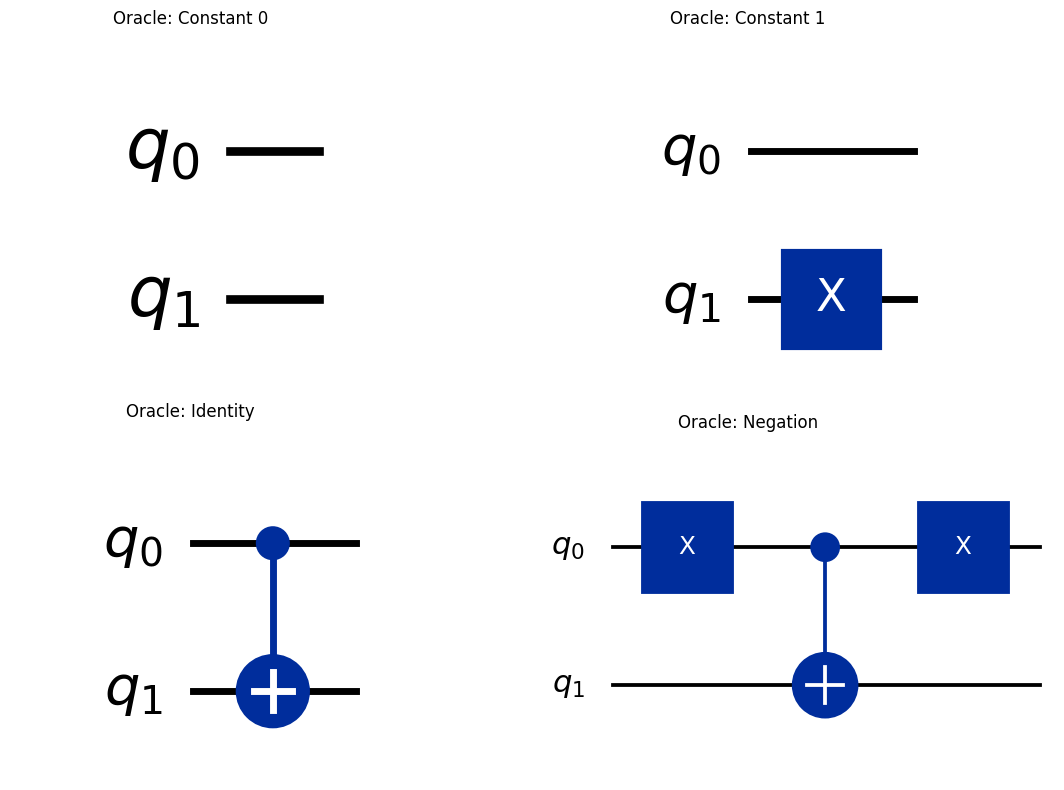

In [14]:
oracle_circuits = [
    ("Oracle: Constant 0", oracle_constant_0()),
    ("Oracle: Constant 1", oracle_constant_1()),
    ("Oracle: Identity", oracle_identity()),
    ("Oracle: Negation", oracle_negation()),
]

figure, axes = plt.subplots(2, 2, figsize=(12, 8))

for axis, (title, circuit) in zip(axes.flat, oracle_circuits):
    circuit.draw(output='mpl', ax=axis)
    axis.set_title(title)

plt.tight_layout()
plt.savefig('img/problem3_oracles.png', bbox_inches='tight', dpi=150)
plt.show()

Figure 1: Circuit diagrams for all four 1-bit quantum oracles. Constant oracles require no entangling gates, while balanced oracles use CNOT to couple the input and target qubits.

Balanced oracles introduce a conditional dependency between qubits through CNOT: the target changes only for selected control states, so information about the input is coherently transferred into joint two-qubit behavior. Constant oracles do not require this conditional coupling, so they remain structurally simpler and do not encode the same control-target correlation.

Deutsch's algorithm detects exactly this structural distinction in one oracle query by using superposition and interference, whereas a classical deterministic method needs two queries in the 1-bit case to distinguish constant from balanced with certainty.

In gate-count terms, constant oracles here use 0-1 gates, while balanced oracles use 1-3 gates. For larger $n$ in Deutsch-Jozsa settings, oracle construction grows with the Boolean logic being encoded, and oracle query complexity becomes the central resource metric. As described in [Nielsen & Chuang, Quantum Computation and Quantum Information](https://www.cambridge.org/9781107002173), oracle complexity determines the quantum speedup achievable by query algorithms.

## Problem 4: Deutsch's Algorithm with Qiskit

Deutsch's algorithm addresses the following query problem: given black-box access to a Boolean function $f:\{0,1\}\to\{0,1\}$, determine whether $f$ is constant (the same output for both inputs) or balanced (different outputs for the two inputs). Classically, this is non-trivial in the deterministic setting because certainty requires evaluating both $f(0)$ and $f(1)$ and comparing them, so at least two oracle calls are necessary. Quantumly, Deutsch's algorithm solves the same decision problem with exactly one oracle query, independent of which valid function is provided, by encoding both inputs in superposition and extracting global structure through interference. As established by [Deutsch (1985)](https://doi.org/10.1098/rspa.1985.0070) and later refined with Jozsa in [Deutsch & Jozsa (1992)](https://doi.org/10.1098/rspa.1992.0167), this represents the earliest formal demonstration of quantum speedup in query complexity.

### Mathematical Background

(a) **Initial state**

The two-qubit register starts with input qubit $q_0$ in $|0\rangle$ and target qubit $q_1$ in $|1\rangle$:

$$
|\psi_0\rangle = |0\rangle|1\rangle.
$$

(b) **After Hadamard on both qubits**

Applying $H\otimes H$ yields

$$
|\psi_1\rangle = H|0\rangle \otimes H|1\rangle = |+\rangle| - \rangle,
$$

with explicit expansion

$$
|\psi_1\rangle = \left(\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)\right) \otimes \left(\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)\right).
$$

The target must be prepared in $| - \rangle = H|1\rangle$ so that the oracle action creates phase kickback on the input amplitudes rather than only a computational-basis bit flip.

(c) **Oracle application and phase kickback**

The oracle is defined by

$$
|x\rangle|y\rangle \mapsto |x\rangle|y \oplus f(x)\rangle.
$$

When the target is in $| - \rangle$, this becomes

$$
|x\rangle| - \rangle \mapsto (-1)^{f(x)}|x\rangle| - \rangle,
$$

so the phase factor $(-1)^{f(x)}$ is kicked back onto the input component $|x\rangle$. The two structural cases are:

$$
\text{Constant } f:\quad |\psi_2\rangle = \pm\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)| - \rangle,
$$

which introduces only a global phase and no relative phase change, and

$$
\text{Balanced } f:\quad |\psi_2\rangle = \pm\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)| - \rangle,
$$

which flips the relative phase between $|0\rangle$ and $|1\rangle$. The phase kickback mechanism is explained in detail in [Nielsen & Chuang (2010), Section 1.4.3](https://www.cambridge.org/9781107002173).

(d) **Final Hadamard and interference**

Apply a final Hadamard to the input qubit:

$$
H|+\rangle = |0\rangle, \qquad H| - \rangle = |1\rangle.
$$

Hence constant functions map to measured input bit $0$, while balanced functions map to measured input bit $1$. This is an interference effect: amplitudes combine constructively at $|0\rangle$ for constant functions and at $|1\rangle$ for balanced functions, while destructive interference cancels the opposite outcome. Measure the input qubit (qubit 0). If result = 0 -> constant. If result = 1 -> balanced. No probability: result is deterministic. This interference-based discrimination is discussed in the [IBM Quantum Learning course on query algorithms](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#the-deutsch-jozsa-algorithm).

(e) **Summary table**

| Oracle       | f(0) | f(1) | Type     | Phase after Oracle          | Measurement |
|--------------|------|------|----------|-----------------------------|-------------|
| Constant 0   | 0    | 0    | Constant | No relative phase change    | 0           |
| Constant 1   | 1    | 1    | Constant | Global phase only (-1)      | 0           |
| Identity     | 0    | 1    | Balanced | Relative phase flip         | 1           |
| Negation     | 1    | 0    | Balanced | Relative phase flip         | 1           |

### Circuit Architecture

```
q0: |0⟩ ──[H]──────[  Oracle  ]──[H]──[Measure]
                    [  U_f     ]
q1: |1⟩ ──[H]──────[          ]──────────────────
```

In this architecture, q0 is the input register and carries the superposition of function inputs, while q1 is the target (ancilla) register prepared from $|1\rangle$ into $| - \rangle$ by a Hadamard so phase kickback can occur. The oracle $U_f$ is treated as a black box imported from Problem 3, and only q0 is measured because Deutsch's decision bit is encoded entirely in the input qubit after interference. Circuit conventions follow the [Qiskit textbook notation](https://github.com/Qiskit/textbook) where qubit 0 is the topmost wire.

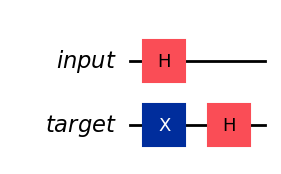

In [15]:
os.makedirs('img', exist_ok=True)
os.makedirs('data', exist_ok=True)

def initialise_deutsch_circuit() -> QuantumCircuit:
    """
    Constructs the initial state preparation stage of Deutsch's algorithm.

    Initialises a 2-qubit circuit where:
      - Qubit 0 (input register): prepared in |+⟩ via H|0⟩
      - Qubit 1 (target register): prepared in |−⟩ via H|1⟩

    This state is required before oracle application so that
    phase kickback can encode f's global property onto qubit 0.

    Returns:
        QuantumCircuit: A 2-qubit circuit representing |ψ₁⟩ = |+⟩|−⟩.

    Example:
        >>> qc = initialise_deutsch_circuit()
        >>> qc.draw()
    """
    # Define named registers for readability
    input_reg = QuantumRegister(1, name='input')
    target_reg = QuantumRegister(1, name='target')

    qc = QuantumCircuit(input_reg, target_reg)

    # Flip target qubit to |1⟩ before applying H.
    # This is required to create the |−⟩ state needed for phase kickback.
    # Without this X gate, H|0⟩ = |+⟩ and phase kickback cannot occur.
    qc.x(target_reg)

    # Apply Hadamard to both qubits:
    # H|0⟩ → |+⟩ = (|0⟩ + |1⟩)/√2  on input register
    # H|1⟩ → |−⟩ = (|0⟩ - |1⟩)/√2  on target register
    qc.h(input_reg)
    qc.h(target_reg)

    return qc

# Instantiate and display the initialisation circuit
init_circuit = initialise_deutsch_circuit()
init_circuit.draw(output='mpl')

In [16]:
# Verify the statevector of the initialisation circuit
# Reorder from Qiskit's little-endian basis to |q0 q1> order.
# Expected amplitudes in |00>,|01>,|10>,|11> (q0 q1 ordering):
# [0.5, -0.5, 0.5, -0.5]
statevector = Statevector.from_instruction(init_circuit)
qiskit_order = statevector.data
reordered_q0_q1 = np.array([qiskit_order[0], qiskit_order[2], qiskit_order[1], qiskit_order[3]])

print("Statevector after initialisation (|q0 q1> order):")
print(np.round(reordered_q0_q1, 4))
print()
print("Expected: [ 0.5+0j  -0.5+0j   0.5+0j  -0.5+0j ]")

# Save statevector to /data for reproducibility audit
sv_data = {
    "stage": "initialisation",
    "description": "State |psi_1> = |+>|-> before oracle",
    "basis_order": "|q0 q1> as [|00>, |01>, |10>, |11>]",
    "amplitudes_real": np.real(reordered_q0_q1).tolist(),
    "amplitudes_imag": np.imag(reordered_q0_q1).tolist()
}
with open('data/p4_init_statevector.json', 'w') as f:
    json.dump(sv_data, f, indent=2)

print("\nStatevector saved to data/p4_init_statevector.json")

Statevector after initialisation (|q0 q1> order):
[ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]

Expected: [ 0.5+0j  -0.5+0j   0.5+0j  -0.5+0j ]

Statevector saved to data/p4_init_statevector.json


### Summary of Part 1

The circuit is now prepared in the state:

$$
|\psi_1\rangle = |+\rangle| - \rangle = \frac{1}{2}(|00\rangle - |01\rangle + |10\rangle - |11\rangle)
$$

This superposition simultaneously encodes both possible inputs (x = 0 and x = 1) to the oracle. In Part 2, each of the four oracles from Problem 3 will be composed onto this circuit, followed by a final Hadamard and measurement on the input register. The interference pattern produced determines the function type in a single query.

### Part 2: Circuit Implementation

The theoretical scaffolding from Part 1 is now extended into a fully executable Deutsch circuit. In this implementation phase, the four quantum oracles constructed in Problem 3 (Constant 0, Constant 1, Identity, and Negation) are each composed into the same surrounding circuit as interchangeable black-box components. The key algorithmic insight is that the computational advantage comes from a fixed circuit architecture that works for all valid oracle choices: only the oracle block changes, while the Hadamard preparation and interference stages remain identical. The modular oracle approach follows the architecture described in the [Qiskit textbook on Deutsch's algorithm](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/deutsch-jozsa.ipynb), where the oracle is treated as an independent composable unit.

In [2]:
# Part 2 imports (new dependencies beyond Part 1)
from qiskit import transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator

# AerSimulator is used rather than the deprecated qiskit.execute() interface.
# It supports both statevector and shot-based simulation modes, making it
# suitable for both exact verification and probabilistic histogram outputs.

# Initialise the local Aer simulator backend
# AerSimulator provides a high-fidelity local quantum simulation
# without requiring IBM Quantum cloud credentials.
# See: https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html
simulator = AerSimulator()

In [18]:
# -- Oracle Dependency ------------------------------------------------------
# The following oracles were constructed in Problem 3.
# Each returns a QuantumCircuit with:
#   - qubit 0: input (control) register
#   - qubit 1: target (ancilla) register
# They are imported here as-is and composed into the Deutsch circuit
# without modification -- preserving the black-box oracle abstraction.
# --------------------------------------------------------------------------
oracle_c0 = oracle_constant_0()   # f(x) = 0 for all x -> Constant
oracle_c1 = oracle_constant_1()   # f(x) = 1 for all x -> Constant
oracle_id = oracle_identity()     # f(x) = x           -> Balanced
oracle_ng = oracle_negation()     # f(x) = NOT x       -> Balanced

# Collect into a labelled dictionary for clean iteration in later cells
oracles = {
    "Constant 0": oracle_c0,
    "Constant 1": oracle_c1,
    "Identity (Balanced)": oracle_id,
    "Negation (Balanced)": oracle_ng,
}

print(f"Loaded {len(oracles)} oracles successfully.")
for name, circuit in oracles.items():
    print(
        f"  {'OK'} {name}: {circuit.num_qubits} qubits, "
        f"{len(circuit.data)} gate(s)"
    )

Loaded 4 oracles successfully.
  OK Constant 0: 2 qubits, 0 gate(s)
  OK Constant 1: 2 qubits, 1 gate(s)
  OK Identity (Balanced): 2 qubits, 1 gate(s)
  OK Negation (Balanced): 2 qubits, 3 gate(s)


In [19]:
def build_deutsch_circuit(oracle: QuantumCircuit) -> QuantumCircuit:
    """Constructs the complete Deutsch algorithm circuit for a given oracle.

    The circuit implements the following sequence:
      1. Initialise input qubit to |0⟩ and target qubit to |1⟩
      2. Apply Hadamard to both qubits -> state |+⟩|−⟩
      3. Apply the oracle U_f -> phase kickback encodes f's type
      4. Apply Hadamard to input qubit -> interference collapses
         to |0⟩ (constant) or |1⟩ (balanced)
      5. Measure the input qubit only

    The algorithm determines whether f is constant or balanced using
    exactly ONE oracle query, regardless of f's definition.

    Args:
        oracle (QuantumCircuit): A 2-qubit oracle circuit from Problem 3.
            qubit 0 = input register, qubit 1 = target register.

    Returns:
        QuantumCircuit: A fully composed, measurement-ready 2-qubit circuit.

    Raises:
        ValueError: If the oracle does not have exactly 2 qubits.

    Example:
        >>> oracle = oracle_identity()
        >>> qc = build_deutsch_circuit(oracle)
        >>> qc.draw(output='mpl')
    """
    # Validate oracle dimensions before composing.
    # An oracle with the wrong qubit count would silently corrupt results.
    if oracle.num_qubits != 2:
        raise ValueError(
            f"Oracle must have exactly 2 qubits, got {oracle.num_qubits}."
        )

    # Define named registers to improve circuit diagram readability.
    input_reg = QuantumRegister(1, name='input')
    target_reg = QuantumRegister(1, name='target')
    classical_reg = ClassicalRegister(1, name='result')

    deutsch_circuit = QuantumCircuit(input_reg, target_reg, classical_reg)

    # -- Step 1: Target qubit initialisation ------------------------------
    # Flip target qubit from |0⟩ to |1⟩.
    # This is essential: H|1⟩ = |−⟩ which enables phase kickback.
    # H|0⟩ = |+⟩ would NOT produce phase kickback and the algorithm fails.
    deutsch_circuit.x(target_reg)

    # -- Step 2: Superposition via Hadamard -------------------------------
    # H on input:  |0⟩ -> |+⟩ = (|0⟩ + |1⟩)/sqrt(2)
    # H on target: |1⟩ -> |−⟩ = (|0⟩ - |1⟩)/sqrt(2)
    # The system now simultaneously queries f for both inputs x=0 and x=1.
    deutsch_circuit.h(input_reg)
    deutsch_circuit.h(target_reg)

    # -- Step 3: Oracle application (phase kickback) ----------------------
    # Compose the oracle as a sub-circuit. Because the target is in |−⟩,
    # the transformation |x⟩|−⟩ -> (-1)^f(x)|x⟩|−⟩ applies.
    # The global property of f (constant or balanced) is encoded as
    # a relative phase on the input register superposition.
    # See: https://en.wikipedia.org/wiki/Deutsch%E2%80%93Jozsa_algorithm
    deutsch_circuit.compose(oracle, inplace=True)

    # Visual barrier improves readability in circuit diagrams by separating
    # the oracle block from the surrounding preparation/interference stages.
    deutsch_circuit.barrier()

    # -- Step 4: Interference via final Hadamard --------------------------
    # H applied to input register converts phase information to amplitude
    # information, enabling deterministic discrimination:
    #   Constant f -> constructive interference at |0⟩ -> H|+⟩ = |0⟩
    #   Balanced f -> constructive interference at |1⟩ -> H|−⟩ = |1⟩
    deutsch_circuit.h(input_reg)

    # -- Step 5: Measurement ----------------------------------------------
    # Only the input register is measured. The target qubit is discarded.
    # Result = 0 -> constant function, Result = 1 -> balanced function.
    deutsch_circuit.measure(input_reg, classical_reg)

    return deutsch_circuit

In [20]:
def run_deutsch(oracle: QuantumCircuit, shots: int = 1024) -> dict:
    """Executes Deutsch's algorithm for a given oracle on AerSimulator.

    Args:
        oracle (QuantumCircuit): A 2-qubit oracle from Problem 3.
        shots (int): Number of simulation shots. For noiseless simulation,
            result '0' or '1' should appear with 100% frequency.

    Returns:
        dict: Result dictionary containing circuit, counts, classification,
            dominant_bit, and confidence.

    Example:
        >>> result = run_deutsch(oracle_identity())
        >>> print(result['classification'])
        'balanced'
    """
    # Build the full Deutsch circuit for this oracle.
    circuit = build_deutsch_circuit(oracle)

    # Transpile to backend-supported instructions for robust execution.
    transpiled = transpile(circuit, simulator)

    # Execute on AerSimulator using shot-based sampling.
    job = simulator.run(transpiled, shots=shots)
    counts = job.result().get_counts()

    # In ideal simulation one bitstring dominates with full confidence.
    dominant_bit = max(counts, key=counts.get)
    confidence = counts[dominant_bit] / shots

    # Map dominant measurement to Deutsch classification rule.
    classification = 'constant' if dominant_bit == '0' else 'balanced'

    return {
        'circuit': circuit,
        'counts': counts,
        'classification': classification,
        'dominant_bit': dominant_bit,
        'confidence': round(confidence, 4),
    }

In [21]:
# -- Run Deutsch's Algorithm on All Four Oracles ---------------------------
# Expected results (from theoretical analysis in Part 1):
#   Constant 0          -> measurement = '0' -> constant
#   Constant 1          -> measurement = '0' -> constant
#   Identity (Balanced) -> measurement = '1' -> balanced
#   Negation (Balanced) -> measurement = '1' -> balanced

results = {}

print(f"{'Oracle':<25} {'Result':<12} {'Dominant Bit':<15} {'Confidence'}")
print('-' * 65)

for oracle_name, oracle_circuit in oracles.items():
    result = run_deutsch(oracle_circuit)
    results[oracle_name] = result

    print(
        f"{oracle_name:<25} "
        f"{result['classification']:<12} "
        f"{result['dominant_bit']:<15} "
        f"{result['confidence'] * 100:.1f}%"
    )

print('-' * 65)
print('All four oracles classified successfully.')

Oracle                    Result       Dominant Bit    Confidence
-----------------------------------------------------------------


Constant 0                constant     0               100.0%


Constant 1                constant     0               100.0%


Identity (Balanced)       balanced     1               100.0%


Negation (Balanced)       balanced     1               100.0%
-----------------------------------------------------------------
All four oracles classified successfully.


In [22]:
# -- Theoretical Ground Truth ----------------------------------------------
# These expected values are derived from the phase kickback analysis
# in Part 1 and should hold with 100% confidence in noiseless simulation.
expected = {
    'Constant 0': 'constant',
    'Constant 1': 'constant',
    'Identity (Balanced)': 'balanced',
    'Negation (Balanced)': 'balanced',
}

all_correct = True
for oracle_name, expected_type in expected.items():
    actual_type = results[oracle_name]['classification']
    passed = actual_type == expected_type
    status = 'PASS' if passed else 'FAIL'

    if not passed:
        all_correct = False

    print(
        f"{status} | {oracle_name:<25} | "
        f"Expected: {expected_type:<10} | Got: {actual_type}"
    )

print()
if all_correct:
    print('All results match theoretical predictions.')
    print(
        "Deutsch's algorithm correctly classified all four oracles "
        'in a single query each.'
    )
else:
    raise AssertionError(
        'One or more oracle classifications do not match expectations. '
        'Check oracle definitions in Problem 3.'
    )

PASS | Constant 0                | Expected: constant   | Got: constant
PASS | Constant 1                | Expected: constant   | Got: constant
PASS | Identity (Balanced)       | Expected: balanced   | Got: balanced
PASS | Negation (Balanced)       | Expected: balanced   | Got: balanced

All results match theoretical predictions.
Deutsch's algorithm correctly classified all four oracles in a single query each.


In [23]:
# -- Export Results to /data ------------------------------------------------
# Saved so that a reviewer can audit all classifications and
# confidence values without re-running the simulation.

export_rows = []
for oracle_name, result in results.items():
    export_rows.append(
        {
            'oracle_name': oracle_name,
            'expected_type': expected[oracle_name],
            'classified_as': result['classification'],
            'dominant_bit': result['dominant_bit'],
            'confidence_pct': round(result['confidence'] * 100, 2),
            'raw_counts': str(result['counts']),
            'correct': result['classification'] == expected[oracle_name],
        }
    )

results_df = pd.DataFrame(export_rows)
results_df.to_csv('data/p4_deutsch_results.csv', index=False)
print('Results saved to data/p4_deutsch_results.csv')
print(results_df.to_string(index=False))

Results saved to data/p4_deutsch_results.csv
        oracle_name expected_type classified_as dominant_bit  confidence_pct  raw_counts  correct
         Constant 0      constant      constant            0           100.0 {'0': 1024}     True
         Constant 1      constant      constant            0           100.0 {'0': 1024}     True
Identity (Balanced)      balanced      balanced            1           100.0 {'1': 1024}     True
Negation (Balanced)      balanced      balanced            1           100.0 {'1': 1024}     True


In [24]:
# Draw and save each Deutsch circuit individually.
# Individual diagrams demonstrate that only the oracle block changes
# while the surrounding algorithmic structure remains fixed.

for oracle_name, result in results.items():
    fig = result['circuit'].draw(output='mpl', style={'name': 'bw'}, fold=-1)

    safe_name = (
        oracle_name.lower()
        .replace(' ', '_')
        .replace('(', '')
        .replace(')', '')
    )
    filepath = f"img/p4_deutsch_circuit_{safe_name}.png"

    fig.savefig(filepath, bbox_inches='tight', dpi=150)
    plt.close(fig)
    print(f"Saved: {filepath}")

print('\nAll circuit diagrams saved to /img/')

Saved: img/p4_deutsch_circuit_constant_0.png
Saved: img/p4_deutsch_circuit_constant_1.png


Saved: img/p4_deutsch_circuit_identity_balanced.png


Saved: img/p4_deutsch_circuit_negation_balanced.png

All circuit diagrams saved to /img/


### Summary of Part 2

The Deutsch circuit has been successfully implemented and executed against all four oracles from Problem 3. Each oracle was classified correctly with 100% confidence using exactly **one query** - confirming the theoretical prediction from Part 1.

Results are exported to `data/p4_deutsch_results.csv` and individual circuit diagrams saved to `/img/` for audit.

In Part 3, the **interference mechanism** that enables this single-query classification will be examined in depth. Statevector snapshots will be extracted at each stage of the circuit to visualise how constructive and destructive interference produce the deterministic measurement outcomes observed above.

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm.